# Leaf Dataset Preprocessing
`archive(2)/New_data` -> grouped train/val/test split, class weights, augmentation pipeline.

**Why a grouped split:** many images are multiple crops of the same source photo
(filenames like `IMG_<date>_<time>.jpg` and `IMG_<date>_<time>_1.jpg`). A random
per-image split would let crops of the same photo leak across train/val/test and
inflate accuracy. This notebook splits at the *source photo* level instead.

Output: `data/train|val|test/<class>/*.jpg`, `data/split_manifest.csv`, `data/class_weights.json`.


In [1]:
import os, re, json, shutil, random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

import albumentations as A
from albumentations.pytorch import ToTensorV2

import torch
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


## Config

In [2]:
SOURCE_DIR = Path("archive(2)/New_data")
DATA_DIR = Path("data")

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15
assert abs(TRAIN_RATIO + VAL_RATIO + TEST_RATIO - 1.0) < 1e-9

IMG_SIZE = 224

CLASSES = sorted(d.name for d in SOURCE_DIR.iterdir() if d.is_dir())
print(f"{len(CLASSES)} classes: {CLASSES}")


8 classes: ['Apple', 'Berry', 'Fig', 'Guava', 'Orange', 'Palm', 'Persimmon', 'Tomato']


## Scan files & derive source-photo group id

Filenames follow `IMG_<date>_<time>.jpg` with extra crops of the same photo suffixed
`_1`, `_2`, etc. Stripping that suffix recovers the original photo id, which becomes
the grouping key for the split.

In [3]:
def base_photo_id(filename: str) -> str:
    return re.sub(r'_\d{1,2}\.jpg$', '.jpg', filename, flags=re.IGNORECASE)

records = []
for cls in CLASSES:
    for fpath in sorted((SOURCE_DIR / cls).glob("*.jpg")):
        records.append({
            "filepath": str(fpath),
            "filename": fpath.name,
            "label": cls,
            "photo_id": base_photo_id(fpath.name),
        })

df = pd.DataFrame(records)
df["group_key"] = df["label"] + "::" + df["photo_id"]

print(f"Total images: {len(df)}")
print(f"Total unique source photos (groups): {df['group_key'].nunique()}")
df.head()


Total images: 3588
Total unique source photos (groups): 1858


,filepath,filename,label,photo_id,group_key
0,archive(2)/New_data/Apple/IMG_20240710_161156.jpg,IMG_20240710_161156.jpg,Apple,IMG_20240710_161156.jpg,Apple::IMG_20240710_161156.jpg
1,archive(2)/New_data/Apple/IMG_20240710_161156_...,IMG_20240710_161156_1.jpg,Apple,IMG_20240710_161156.jpg,Apple::IMG_20240710_161156.jpg
2,archive(2)/New_data/Apple/IMG_20240710_161157.jpg,IMG_20240710_161157.jpg,Apple,IMG_20240710_161157.jpg,Apple::IMG_20240710_161157.jpg
3,archive(2)/New_data/Apple/IMG_20240710_161157_...,IMG_20240710_161157_1.jpg,Apple,IMG_20240710_161157.jpg,Apple::IMG_20240710_161157.jpg
4,archive(2)/New_data/Apple/IMG_20240710_161157_...,IMG_20240710_161157_2.jpg,Apple,IMG_20240710_161157.jpg,Apple::IMG_20240710_161157.jpg


## Grouped, stratified train / val / test split

Split at the *group* (source photo) level, stratified by class, so every crop of a given photo ends up in the same split.

In [4]:
groups_df = df.groupby(["group_key", "label"], as_index=False).size()
print(f"Total groups: {len(groups_df)}")

# train vs (val+test)
train_groups, temp_groups = train_test_split(
    groups_df,
    test_size=(VAL_RATIO + TEST_RATIO),
    stratify=groups_df["label"],
    random_state=RANDOM_SEED,
)

# val vs test
relative_test_size = TEST_RATIO / (VAL_RATIO + TEST_RATIO)
val_groups, test_groups = train_test_split(
    temp_groups,
    test_size=relative_test_size,
    stratify=temp_groups["label"],
    random_state=RANDOM_SEED,
)

split_map = {}
split_map.update({gk: "train" for gk in train_groups["group_key"]})
split_map.update({gk: "val" for gk in val_groups["group_key"]})
split_map.update({gk: "test" for gk in test_groups["group_key"]})

df["split"] = df["group_key"].map(split_map)
assert df["split"].isna().sum() == 0
print(df["split"].value_counts())


Total groups: 1858
split
train    2510
test      543
val       535
Name: count, dtype: int64


### Leakage check
No source photo (group) may appear in more than one split.

In [5]:
train_g = set(df.loc[df.split == "train", "group_key"])
val_g = set(df.loc[df.split == "val", "group_key"])
test_g = set(df.loc[df.split == "test", "group_key"])

assert train_g.isdisjoint(val_g)
assert train_g.isdisjoint(test_g)
assert val_g.isdisjoint(test_g)
print("OK: no source photo appears in more than one split.")


OK: no source photo appears in more than one split.


In [6]:
summary = df.pivot_table(index="label", columns="split", values="filename", aggfunc="count", fill_value=0)
summary = summary[["train", "val", "test"]]
summary["total"] = summary.sum(axis=1)
summary.loc["TOTAL"] = summary.sum()
summary


split,train,val,test,total
label,,,,
Apple,365,75,79,519
Berry,239,47,54,340
Fig,349,82,77,508
Guava,366,78,76,520
Orange,377,87,83,547
Palm,328,73,67,468
Persimmon,374,70,83,527
Tomato,112,23,24,159
TOTAL,2510,535,543,3588


### Class distribution per split

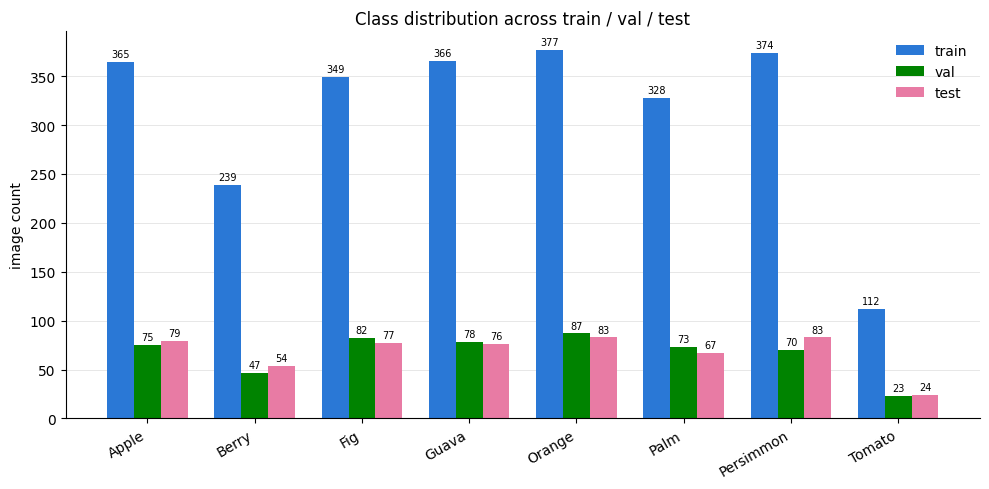

In [7]:
# Fixed categorical order (never cycled): train, val, test
SPLIT_COLORS = {"train": "#2a78d6", "val": "#008300", "test": "#e87ba4"}

plot_df = summary.drop(index="TOTAL")
splits = ["train", "val", "test"]
x = np.arange(len(plot_df.index))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
for i, split in enumerate(splits):
    bars = ax.bar(x + (i - 1) * width, plot_df[split], width,
                   label=split, color=SPLIT_COLORS[split])
    ax.bar_label(bars, fontsize=7, padding=2)

ax.set_xticks(x)
ax.set_xticklabels(plot_df.index, rotation=30, ha="right")
ax.set_ylabel("image count")
ax.set_title("Class distribution across train / val / test")
ax.spines[["top", "right"]].set_visible(False)
ax.yaxis.grid(True, linewidth=0.5, color="#dddddd", zorder=0)
ax.set_axisbelow(True)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


## Create `data/` folder structure and copy images

In [8]:
for split in ["train", "val", "test"]:
    for cls in CLASSES:
        (DATA_DIR / split / cls).mkdir(parents=True, exist_ok=True)

for row in tqdm(df.itertuples(index=False), total=len(df), desc="Copying images"):
    dest = DATA_DIR / row.split / row.label / row.filename
    if not dest.exists():
        shutil.copy2(row.filepath, dest)

print("Done.")


Copying images:   0%|          | 0/3588 [00:00<?, ?it/s]

Done.


In [9]:
for split in ["train", "val", "test"]:
    n_copied = sum(len(list((DATA_DIR / split / cls).glob("*.jpg"))) for cls in CLASSES)
    n_expected = int((df.split == split).sum())
    status = "OK" if n_copied == n_expected else "MISMATCH"
    print(f"{split:5s}: expected {n_expected:4d}, copied {n_copied:4d}  [{status}]")
    assert n_copied == n_expected


train: expected 2510, copied 2510  [OK]
val  : expected  535, copied  535  [OK]
test : expected  543, copied  543  [OK]


## Save split manifest + class weights

In [10]:
manifest_path = DATA_DIR / "split_manifest.csv"
df.to_csv(manifest_path, index=False)
print(f"Manifest saved to {manifest_path} ({len(df)} rows)")


Manifest saved to data/split_manifest.csv (3588 rows)


In [11]:
train_labels = df.loc[df.split == "train", "label"].values
weights_arr = compute_class_weight(class_weight="balanced", classes=np.array(CLASSES), y=train_labels)
class_weights = {cls: float(w) for cls, w in zip(CLASSES, weights_arr)}

print("Class weights (balanced, computed on the train split only):")
for cls, w in sorted(class_weights.items(), key=lambda kv: -kv[1]):
    print(f"  {cls:12s}: {w:.3f}")

with open(DATA_DIR / "class_weights.json", "w") as f:
    json.dump(class_weights, f, indent=2)

# Ready to hand to nn.CrossEntropyLoss(weight=...)
class_weights_tensor = torch.tensor([class_weights[c] for c in CLASSES], dtype=torch.float32)
class_weights_tensor


Class weights (balanced, computed on the train split only):
  Tomato      : 2.801
  Berry       : 1.313
  Palm        : 0.957
  Fig         : 0.899
  Apple       : 0.860
  Guava       : 0.857
  Persimmon   : 0.839
  Orange      : 0.832


tensor([0.8596, 1.3128, 0.8990, 0.8572, 0.8322, 0.9566, 0.8389, 2.8013])

## Augmentation pipeline

Train-only augmentation (flip, rotation, color jitter, random-resized crop) plus the
resize/normalize every split needs. Val/test only get the deterministic resize+normalize
so evaluation reflects real images, not augmented ones.

In [12]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.Rotate(limit=25, border_mode=0, fill=0, p=0.6),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=10, p=0.4),
    A.RandomResizedCrop(size=(IMG_SIZE, IMG_SIZE), scale=(0.8, 1.0), p=0.5),
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

eval_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])


### Visual sanity check
Apply the train-time augmentation to one sample image several times and look at the result.

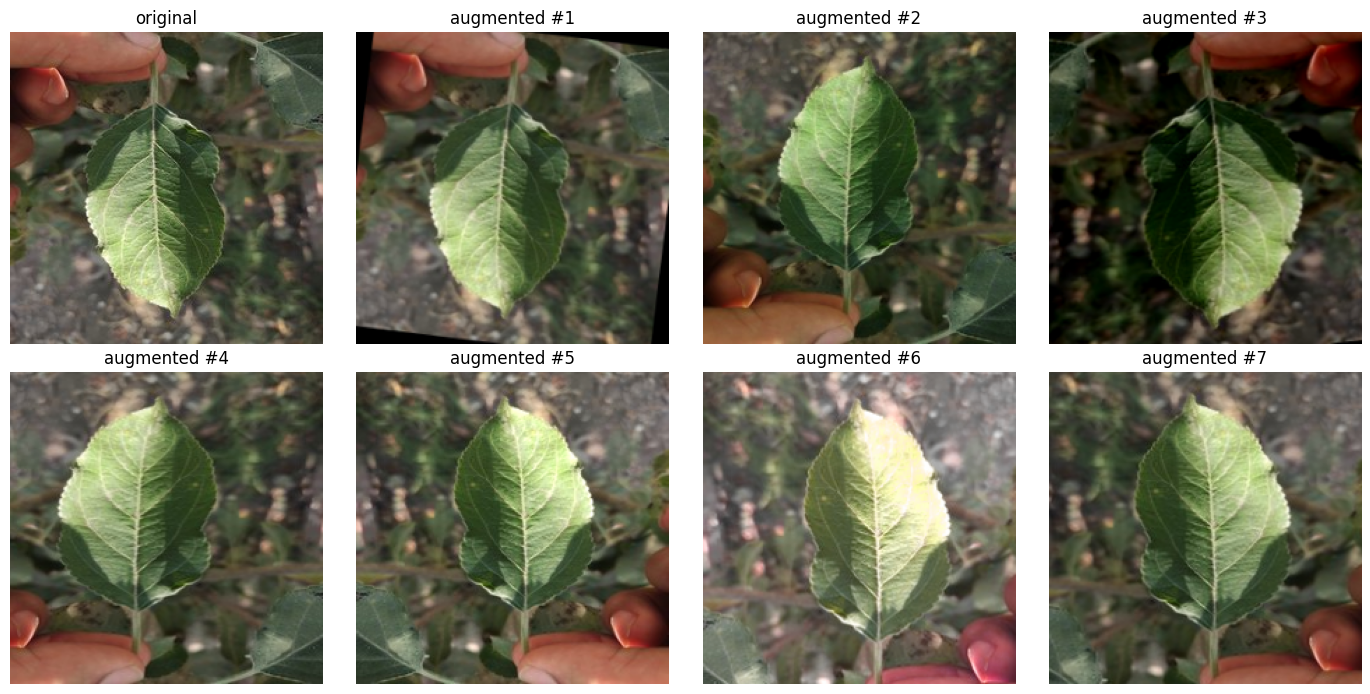

In [13]:
sample_path = df.loc[df.split == "train", "filepath"].iloc[0]
sample_img = np.array(Image.open(sample_path).convert("RGB"))

def denormalize(tensor):
    img = tensor.permute(1, 2, 0).numpy()
    img = img * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    return np.clip(img, 0, 1)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()
axes[0].imshow(sample_img)
axes[0].set_title("original")
for ax in axes:
    ax.axis("off")

for i in range(1, 8):
    augmented = train_transform(image=sample_img)["image"]
    axes[i].imshow(denormalize(augmented))
    axes[i].set_title(f"augmented #{i}")

plt.tight_layout()
plt.show()


## PyTorch `Dataset` / `DataLoader` smoke test

In [14]:
class LeafDataset(Dataset):
    def __init__(self, root_dir, classes, transform=None):
        self.transform = transform
        self.classes = classes
        self.class_to_idx = {c: i for i, c in enumerate(classes)}
        self.samples = []
        for c in classes:
            for p in sorted(Path(root_dir, c).glob("*.jpg")):
                self.samples.append((str(p), self.class_to_idx[c]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = np.array(Image.open(path).convert("RGB"))
        if self.transform:
            image = self.transform(image=image)["image"]
        return image, label


train_ds = LeafDataset(DATA_DIR / "train", CLASSES, transform=train_transform)
val_ds = LeafDataset(DATA_DIR / "val", CLASSES, transform=eval_transform)
test_ds = LeafDataset(DATA_DIR / "test", CLASSES, transform=eval_transform)

print(f"train: {len(train_ds)}  val: {len(val_ds)}  test: {len(test_ds)}")

# num_workers=0 here for a deterministic smoke test; raise it for real training.
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)

xb, yb = next(iter(train_loader))
print("batch images:", xb.shape, xb.dtype)
print("batch labels:", yb.shape, yb.dtype, yb[:10].tolist())


train: 2510  val: 535  test: 543
batch images: torch.Size([32, 3, 224, 224]) torch.float32
batch labels: torch.Size([32]) torch.int64 [0, 5, 3, 6, 5, 1, 1, 0, 0, 3]


## Summary

- `data/train|val|test/<class>/*.jpg` — physically split image folders, grouped by source photo so no crop leaks across splits.
- `data/split_manifest.csv` — every file's original path, class, source-photo group id, and assigned split (for reproducibility / auditing).
- `data/class_weights.json` — balanced class weights computed from the train split only, ready for `nn.CrossEntropyLoss(weight=...)`.
- `train_transform` / `eval_transform` — the augmentation pipeline (train-only augmentation, deterministic resize+normalize for val/test).
- `LeafDataset` / `DataLoader`s — ready to feed into the custom 6-conv CNN.

**Next step:** plug `train_loader` / `val_loader` / `test_loader` and `class_weights_tensor` into the CNN training script.
